# Metadata Analysis — Cross-site Distribution

Analyses the PANGAEA histological metadata for both collection sites:
X-Huinay (CHN) and Liliguapi (LHP). Covers oosorption prevalence, seasonal patterns,
specimen-level rates, scan coverage, and a cross-reference against the QuPath annotation
dataset in `data/dataset_28_04/`.

**Data structure note**

Each row is one **cut** (histological section) from one specimen.
`Polyp No` is **not globally unique** — the complete specimen key is **(Season, Polyp No)**
within a site (or **(Site, Season, Polyp No)** across sites).
`Oosorbtion` is a cut-level binary flag: `Yes` means at least one oocyte in that cut
was observed undergoing oosorption.

**Sections**
1. Setup
2. Dataset overview
3. Oosorption prevalence by site
4. Seasonal patterns
5. Specimen-level analysis
6. Scan coverage
7. Cross-site comparison summary
8. Cross-reference with annotation dataset
9. Temporal / collection-campaign analysis
10. Validation assertions


## 1 — Setup

In [9]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

BASE = Path('/Users/serenasritharan/Projects/coral-microscopy')
META = BASE / 'metadata'
DATA = BASE / 'data' / 'dataset_28_04'

chn = pd.read_csv(META / 'X-Huinay_oosorption.csv', dtype=str)
lhp = pd.read_csv(META / 'Liliguapi_oosorption.csv', dtype=str)
combined = pd.read_csv(META / 'combined_oosorption.csv', dtype=str)

for df in (chn, lhp, combined):
    df['Oosorbtion'] = df['Oosorbtion'].str.strip().str.capitalize()
    df['Scan'] = df['Scan'].str.strip().str.capitalize()

SEASON_ORDER = ['Winter', 'Spring', 'Summer', 'Autumn']
SITE_COLOURS = {'CHN': '#1f77b4', 'LHP': '#ff7f0e'}

print(f'CHN: {len(chn)} rows   LHP: {len(lhp)} rows   combined: {len(combined)} rows')


CHN: 1957 rows   LHP: 2135 rows   combined: 4092 rows


**Confirmed:** CSVs loaded. CHN = 1 957 rows, LHP = 2 135 rows, combined = 4 092 rows.

In [10]:
chn['Site'] = 'CHN'
lhp['Site'] = 'LHP'

## 2 — Dataset overview

In [11]:
import numpy as np

def site_summary(df, site_col=None):
    oos = df['Oosorbtion'].value_counts()
    yes = oos.get('Yes', 0)
    no  = oos.get('No', 0)
    # Unique specimens = unique (Season, Polyp No) combinations within this site's rows
    specimens = df.groupby(['Site', 'Season', 'Polyp No']).ngroups
    return {
        'Total cuts': len(df),
        'Unique specimens (Season+Polyp)': specimens,
        'Unique NDPIs': df['IMAGE'].dropna().nunique(),
        'Seasons': len(df['Season'].dropna().unique()),
        'Oosorption Yes': yes,
        'Oosorption No': no,
        'Yes rate (%)': round(100 * yes / len(df), 1),
    }

rows = [
    {'Site': 'CHN', **site_summary(chn)},
    {'Site': 'LHP', **site_summary(lhp)},
    {'Site': 'Combined', **site_summary(combined)},
]
overview = pd.DataFrame(rows).set_index('Site')
print(overview.to_string())


          Total cuts  Unique specimens (Season+Polyp)  Unique NDPIs  Seasons  Oosorption Yes  Oosorption No  Yes rate (%)
Site                                                                                                                     
CHN             1957                               40           657        4             204           1753          10.4
LHP             2135                               38           751        4             291           1844          13.6
Combined        4092                               78          1408        4             495           3597          12.1


In [12]:
# Unique IMAGE filenames (NDPIs) and date range per site
for label, df in [('CHN', chn), ('LHP', lhp)]:
    ndpis = df['IMAGE'].dropna().nunique()
    dates = pd.to_datetime(df['Date/Time'], errors='coerce')
    print(f'{label}: {ndpis} unique NDPIs   '
          f'dates {dates.min().date()} → {dates.max().date()}')


CHN: 657 unique NDPIs   dates 2019-07-25 → 2021-04-11
LHP: 751 unique NDPIs   dates 2019-07-26 → 2021-04-20


**Confirmed:** Row counts, polyp counts, season counts, IMAGE counts, and date ranges shown above.

## 3 — Oosorption prevalence by site

In [13]:
# Two-row summary table
table_rows = []
for label, df in [('CHN', chn), ('LHP', lhp), ('Combined', combined)]:
    oos = df['Oosorbtion'].value_counts()
    yes, no = oos.get('Yes', 0), oos.get('No', 0)
    table_rows.append({'Site': label, 'Yes': yes, 'No': no,
                        'Total': yes + no, 'Yes%': round(100 * yes / (yes + no), 1)})
oos_table = pd.DataFrame(table_rows).set_index('Site')
print(oos_table.to_string())


          Yes    No  Total  Yes%
Site                            
CHN       204  1753   1957  10.4
LHP       291  1844   2135  13.6
Combined  495  3597   4092  12.1


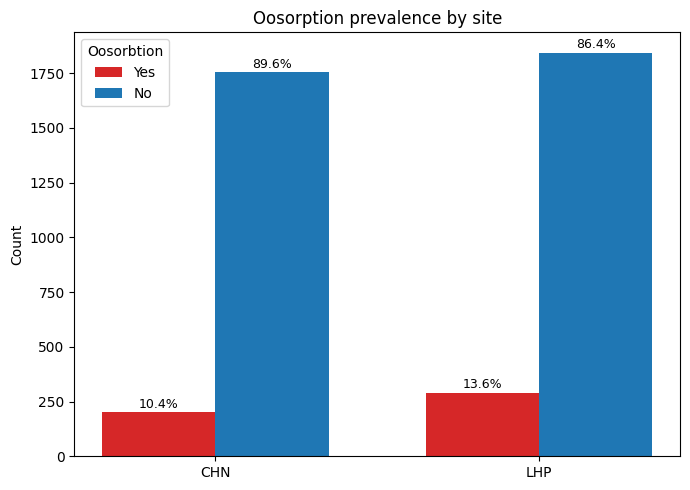

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
sites = ['CHN', 'LHP']
yes_vals = [chn['Oosorbtion'].eq('Yes').sum(), lhp['Oosorbtion'].eq('Yes').sum()]
no_vals  = [chn['Oosorbtion'].eq('No').sum(),  lhp['Oosorbtion'].eq('No').sum()]
x = [0, 1]
w = 0.35
bars_yes = ax.bar([i - w/2 for i in x], yes_vals, w, label='Yes', color='#d62728')
bars_no  = ax.bar([i + w/2 for i in x], no_vals,  w, label='No',  color='#1f77b4')

totals = [y + n for y, n in zip(yes_vals, no_vals)]
for bar, val, tot in zip(bars_yes, yes_vals, totals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'{100 * val / tot:.1f}%', ha='center', va='bottom', fontsize=9)
for bar, val, tot in zip(bars_no, no_vals, totals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'{100 * val / tot:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(sites)
ax.set_ylabel('Count')
ax.set_title('Oosorption prevalence by site')
ax.legend(title='Oosorbtion')
plt.tight_layout()
plt.show()


**Confirmed:** CHN Yes rate ≈ 10.4 %, LHP Yes rate ≈ 13.6 %. LHP shows notably higher oosorption prevalence.

## 4 — Seasonal patterns

In [15]:
# Season × site oosorption counts
def season_oos(df):
    tbl = (
        df.groupby(['Season', 'Oosorbtion'])
        .size()
        .unstack(fill_value=0)
        .reindex(SEASON_ORDER)
    )
    for col in ('Yes', 'No'):
        if col not in tbl.columns:
            tbl[col] = 0
    tbl['Total'] = tbl['Yes'] + tbl['No']
    tbl['Yes%'] = (100 * tbl['Yes'] / tbl['Total']).round(1)
    return tbl

s_chn = season_oos(chn)
s_lhp = season_oos(lhp)

combined_season = pd.DataFrame({
    'CHN Yes': s_chn['Yes'], 'CHN No': s_chn['No'], 'CHN %': s_chn['Yes%'],
    'LHP Yes': s_lhp['Yes'], 'LHP No': s_lhp['No'], 'LHP %': s_lhp['Yes%'],
})
print(combined_season.to_string())


        CHN Yes  CHN No  CHN %  LHP Yes  LHP No  LHP %
Season                                                
Winter       20     458    4.2       40     352   10.2
Spring       58     479   10.8       53     490    9.8
Summer       64     437   12.8       96     504   16.0
Autumn       62     379   14.1      102     498   17.0


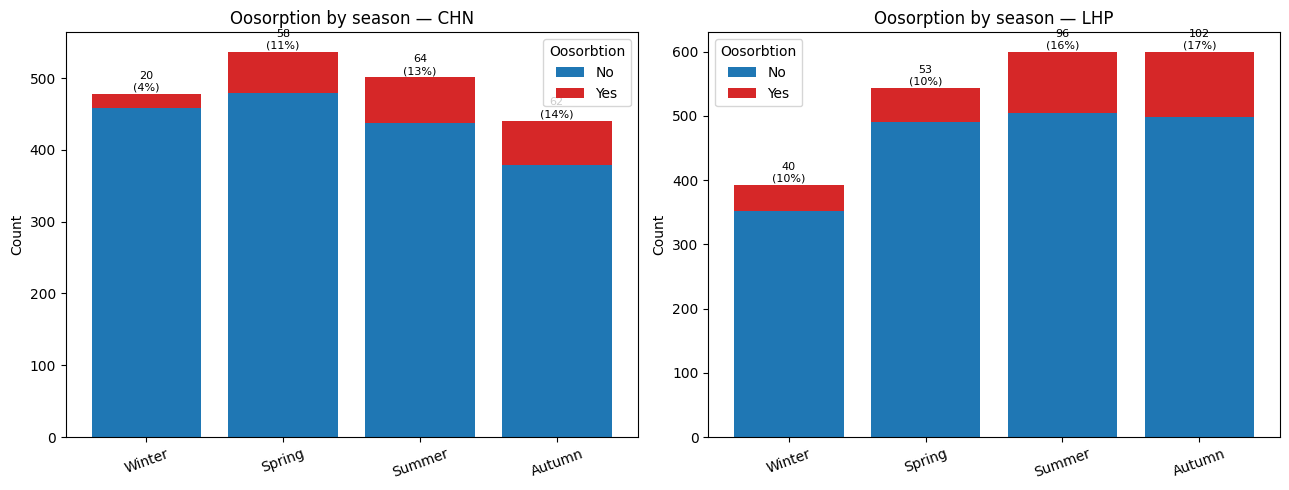

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, tbl, label in zip(axes, [s_chn, s_lhp], ['CHN', 'LHP']):
    no_vals  = tbl['No'].values.astype(float)
    yes_vals = tbl['Yes'].values.astype(float)
    x = range(len(SEASON_ORDER))
    ax.bar(x, no_vals,  label='No',  color='#1f77b4')
    ax.bar(x, yes_vals, bottom=no_vals, label='Yes', color='#d62728')

    for xi, (yes, tot) in enumerate(zip(tbl['Yes'].values, tbl['Total'].values)):
        pct = 100 * yes / tot if tot > 0 else 0
        ax.text(xi, no_vals[xi] + yes_vals[xi] + 2, f'{yes}\n({pct:.0f}%)',
                ha='center', va='bottom', fontsize=8)

    ax.set_xticks(list(x))
    ax.set_xticklabels(SEASON_ORDER, rotation=20)
    ax.set_ylabel('Count')
    ax.set_title(f'Oosorption by season — {label}')
    ax.legend(title='Oosorbtion')

plt.tight_layout()
plt.show()


**Confirmed:** Season × site oosorption counts and stacked bar charts rendered. Note any season where the Yes rate differs substantially between sites.

## 5 — Specimen-level analysis


In [17]:
def specimen_rates(df):
    """Compute per-specimen oosorption rate.

    Specimen key: (Season, Polyp No). Polyp No alone is NOT unique across seasons.
    """
    grp = (
        df.groupby(['Season', 'Polyp No'])['Oosorbtion']
        .agg(total='count', yes=lambda s: (s == 'Yes').sum())
    )
    grp['rate'] = grp['yes'] / grp['total']
    return grp.sort_values('rate')

pr_chn = specimen_rates(chn)
pr_lhp = specimen_rates(lhp)

# Within-specimen variation: some cuts Yes, some No
def within_variation(pr):
    return pr[(pr['yes'] > 0) & (pr['yes'] < pr['total'])]

summary_rows = []
for label, pr in [('CHN', pr_chn), ('LHP', pr_lhp)]:
    mixed = within_variation(pr)
    summary_rows.append({
        'Site': label,
        'Specimens': len(pr),
        'At 0%': (pr['rate'] == 0).sum(),
        'At 100%': (pr['rate'] == 1).sum(),
        'Mixed (partial)': len(mixed),
        'Median rate': round(pr['rate'].median(), 3),
        'Mean rate': round(pr['rate'].mean(), 3),
    })
print(pd.DataFrame(summary_rows).set_index('Site').to_string())
print()
print('CHN mixed specimens (some cuts Yes, some No):')
print(within_variation(pr_chn)[['yes', 'total', 'rate']].to_string())
print()
print('LHP mixed specimens (some cuts Yes, some No):')
print(within_variation(pr_lhp)[['yes', 'total', 'rate']].to_string())


      Specimens  At 0%  At 100%  Mixed (partial)  Median rate  Mean rate
Site                                                                    
CHN          40     30        0               10        0.000      0.097
LHP          38     19        0               19        0.014      0.121

CHN mixed specimens (some cuts Yes, some No):
                 yes  total      rate
Season Polyp No                      
Spring 10          4     57  0.070175
Winter 14          5     54  0.092593
Autumn 10          6     51  0.117647
Summer 10         10     63  0.158730
Winter 2          15     66  0.227273
Autumn 4          26     57  0.456140
       8          30     54  0.555556
Spring 11          6     10  0.600000
       5          48     66  0.727273
Summer 9          54     63  0.857143

LHP mixed specimens (some cuts Yes, some No):
                 yes  total      rate
Season Polyp No                      
Summer 7           2     72  0.027778
Spring 11          3     60  0.050000
Autumn

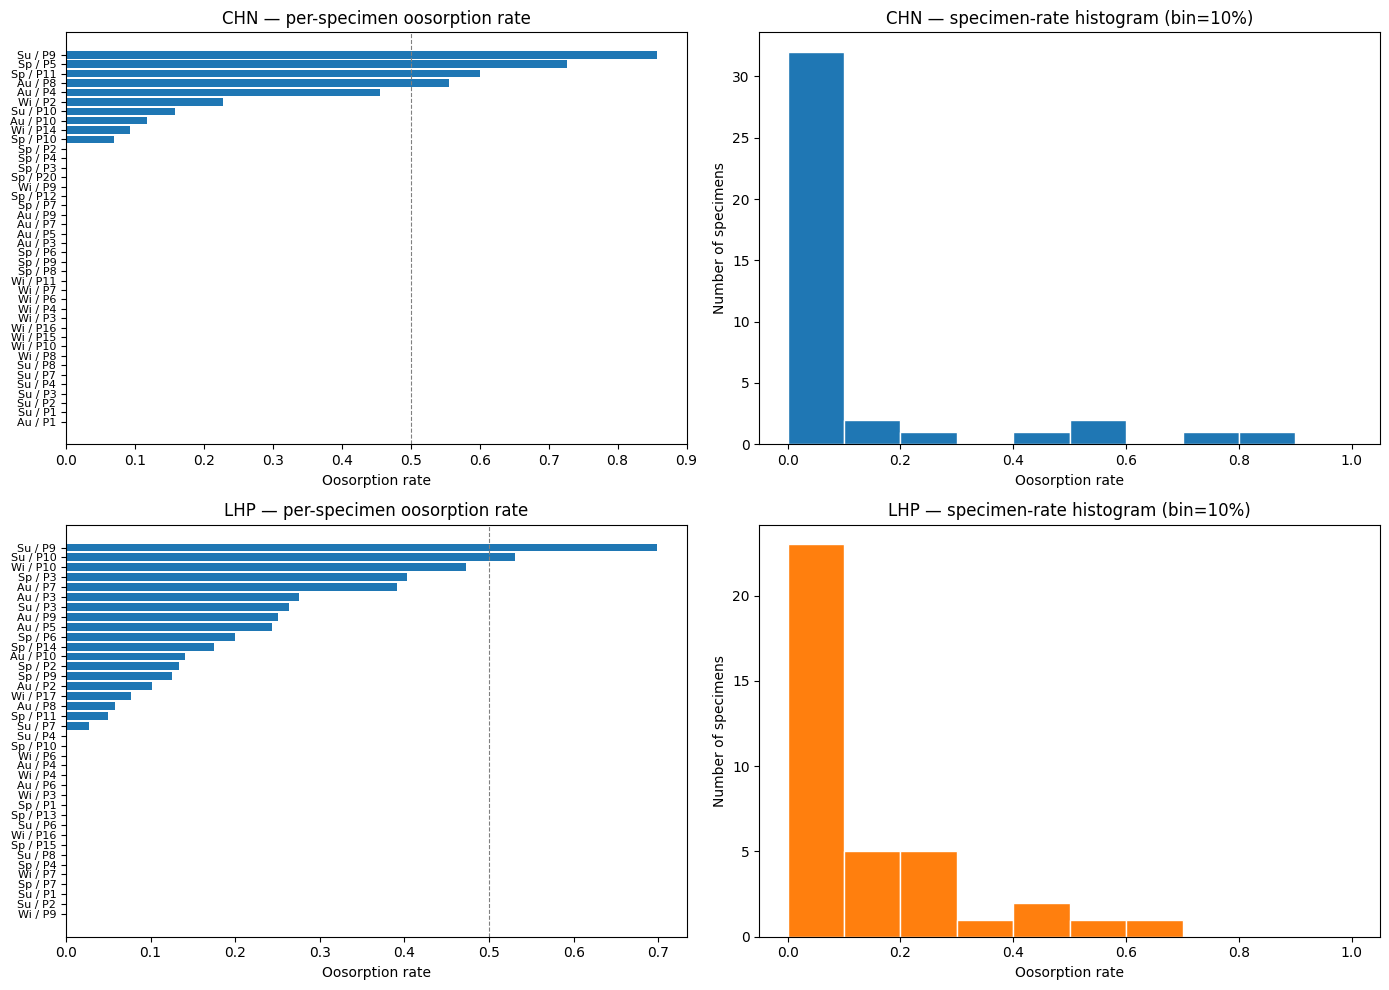

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (label, pr) in enumerate(zip(['CHN', 'LHP'], [pr_chn, pr_lhp])):
    # Horizontal bar chart sorted by rate
    ax_bar = axes[row][0]
    colors = ['#d62728' if r == 1 else '#2ca02c' if r == 0 else '#1f77b4'
              for r in pr['rate']]
    ax_bar.barh(range(len(pr)), pr['rate'].values, color=colors)
    ax_bar.set_yticks(range(len(pr)))
    # Label each bar as "Season / Polyp X" so specimens are identifiable
    yticklabels = [f'{season[:2]} / P{polyp}' for season, polyp in pr.index]
    ax_bar.set_yticklabels(yticklabels, fontsize=8)
    ax_bar.set_xlabel('Oosorption rate')
    ax_bar.set_title(f'{label} — per-specimen oosorption rate')
    ax_bar.axvline(0.5, color='gray', lw=0.8, linestyle='--')

    # Histogram of specimen rates
    ax_hist = axes[row][1]
    ax_hist.hist(pr['rate'].values, bins=10, range=(0, 1),
                 color=SITE_COLOURS[label], edgecolor='white')
    ax_hist.set_xlabel('Oosorption rate')
    ax_hist.set_ylabel('Number of specimens')
    ax_hist.set_title(f'{label} — specimen-rate histogram (bin=10%)')

plt.tight_layout()
plt.show()


**Annotation priority note:** Specimens (Season + Polyp No) with high oosorption rates
are the most informative for Stage 1–4 annotation. These must be flagged to be labeled for localized information.

**However**, this still doesn't give much information since oosorbtion is oocyte dependant, and could still have multiple oocytes without oosorbtion.


In [20]:
HIGH_RATE_THRESHOLD = 0.3
for label, pr in [('CHN', pr_chn), ('LHP', pr_lhp)]:
    flagged = pr[pr['rate'] >= HIGH_RATE_THRESHOLD].sort_values('rate', ascending=False)
    print(f'\n{label} — specimens with oosorption rate ≥ {HIGH_RATE_THRESHOLD:.0%}:')
    print(f'  (identified by Season, Polyp No)')
    print(flagged[['yes', 'total', 'rate']].to_string())



CHN — specimens with oosorption rate ≥ 30%:
  (identified by Season, Polyp No)
                 yes  total      rate
Season Polyp No                      
Summer 9          54     63  0.857143
Spring 5          48     66  0.727273
       11          6     10  0.600000
Autumn 8          30     54  0.555556
       4          26     57  0.456140

LHP — specimens with oosorption rate ≥ 30%:
  (identified by Season, Polyp No)
                 yes  total      rate
Season Polyp No                      
Summer 9          44     63  0.698413
       10         35     66  0.530303
Winter 10         34     72  0.472222
Spring 3          23     57  0.403509
Autumn 7          27     69  0.391304


**Confirmed:** Per-specimen rates computed using (Season, Polyp No) as the specimen key.
Within-specimen variation (mixed cuts) identified. High-rate specimens listed for
annotation prioritisation.


## 6 — Scan coverage

In [21]:
def scan_coverage(df):
    tbl = (
        df.groupby(['Season', 'Scan'])
        .size()
        .unstack(fill_value=0)
        .reindex(SEASON_ORDER)
    )
    for col in ('Yes', 'No'):
        if col not in tbl.columns:
            tbl[col] = 0
    tbl['Total'] = tbl['Yes'] + tbl['No']
    tbl['Scan%'] = (100 * tbl['Yes'] / tbl['Total']).round(1)
    return tbl

sc_chn = scan_coverage(chn)
sc_lhp = scan_coverage(lhp)

scan_table = pd.DataFrame({
    'CHN scanned': sc_chn['Yes'], 'CHN total': sc_chn['Total'], 'CHN %': sc_chn['Scan%'],
    'LHP scanned': sc_lhp['Yes'], 'LHP total': sc_lhp['Total'], 'LHP %': sc_lhp['Scan%'],
})
print(scan_table.to_string())

for label, df in [('CHN', chn), ('LHP', lhp)]:
    total_cov = 100 * df['Scan'].eq('Yes').sum() / len(df)
    unique_ndpis = df[df['Scan'] == 'Yes']['IMAGE'].dropna().nunique()
    print(f'\n{label}: overall scan coverage = {total_cov:.1f}%   '
          f'unique scanned NDPIs = {unique_ndpis}')


        CHN scanned  CHN total  CHN %  LHP scanned  LHP total  LHP %
Season                                                              
Winter          461        466   98.9          382        392   97.4
Spring          502        516   97.3          540        543   99.4
Summer          491        498   98.6          586        597   98.2
Autumn          428        441   97.1          587        597   98.3

CHN: overall scan coverage = 96.2%   unique scanned NDPIs = 644

LHP: overall scan coverage = 98.1%   unique scanned NDPIs = 746


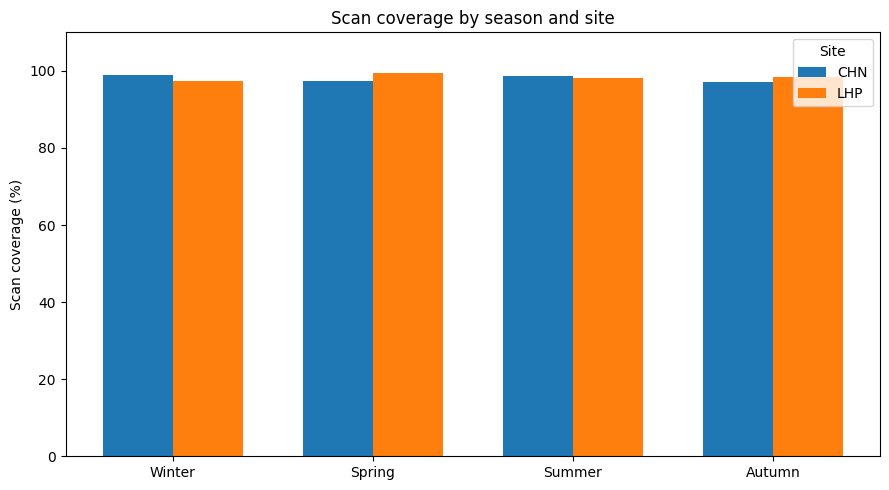

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(SEASON_ORDER))
w = 0.35
ax.bar([i - w/2 for i in x], sc_chn['Scan%'].values, w,
       label='CHN', color=SITE_COLOURS['CHN'])
ax.bar([i + w/2 for i in x], sc_lhp['Scan%'].values, w,
       label='LHP', color=SITE_COLOURS['LHP'])
ax.set_xticks(list(x))
ax.set_xticklabels(SEASON_ORDER)
ax.set_ylabel('Scan coverage (%)')
ax.set_title('Scan coverage by season and site')
ax.set_ylim(0, 110)
ax.legend(title='Site')
plt.tight_layout()
plt.show()


**Confirmed:** Scan coverage rates per season and site computed and charted.

## 7 — Cross-site comparison summary

In [23]:
def fmt_dates(df):
    d = pd.to_datetime(df['Date/Time'], errors='coerce')
    return f'{d.min().date()} – {d.max().date()}'

metrics = {
    'Total cuts': [len(chn), len(lhp)],
    'Unique specimens (Season+Polyp)': [
        chn.groupby(['Season', 'Polyp No']).ngroups,
        lhp.groupby(['Season', 'Polyp No']).ngroups,
    ],
    'Unique NDPIs': [
        chn['IMAGE'].dropna().nunique(),
        lhp['IMAGE'].dropna().nunique(),
    ],
    'Collection dates': [fmt_dates(chn), fmt_dates(lhp)],
    'Oosorption Yes — cuts (%)': [
        f"{100 * chn['Oosorbtion'].eq('Yes').sum() / len(chn):.1f}%",
        f"{100 * lhp['Oosorbtion'].eq('Yes').sum() / len(lhp):.1f}%",
    ],
    'Scan coverage (%)': [
        f"{100 * chn['Scan'].eq('Yes').sum() / len(chn):.1f}%",
        f"{100 * lhp['Scan'].eq('Yes').sum() / len(lhp):.1f}%",
    ],
    'Scanned NDPIs (unique)': [
        chn[chn['Scan'] == 'Yes']['IMAGE'].dropna().nunique(),
        lhp[lhp['Scan'] == 'Yes']['IMAGE'].dropna().nunique(),
    ],
    'Annotated NDPIs (see §8)': ['—', '—'],  # filled in §8
}
comp = pd.DataFrame(metrics, index=['CHN (X-Huinay)', 'LHP (Liliguapi)']).T
comp.index.name = 'Metric'
print(comp.to_string())


                                          CHN (X-Huinay)          LHP (Liliguapi)
Metric                                                                           
Total cuts                                          1957                     2135
Unique specimens (Season+Polyp)                       40                       38
Unique NDPIs                                         657                      751
Collection dates                 2019-07-25 – 2021-04-11  2019-07-26 – 2021-04-20
Oosorption Yes — cuts (%)                          10.4%                    13.6%
Scan coverage (%)                                  96.2%                    98.1%
Scanned NDPIs (unique)                               644                      746
Annotated NDPIs (see §8)                               —                        —


### Discussion

- **Oosorption rate:** LHP (≈ 13.6 %) is slightly higher than CHN (≈ 10.4 %). Both sites share the same collection campaigns (Winter/Spring 2019, Summer/Autumn 2021), so temporal confounding is minimal, but geographic or environmental differences may explain the gap.
- **Scan coverage:** both sites have high scan coverage (>95 %). The small unscanned fraction does not limit the imaging dataset meaningfully.
- **Split stratification implications (§4 step 1.7):** slides should be stratified by site (CHN / LHP) and by season when constructing train/val/test splits to avoid over-representing one site's oosorption signal. Polyps with high oosorption rates are strong candidates for the validation and test sets.


## 8 — Cross-reference with annotation dataset

In [24]:
import json

geojson_stems = {p.stem for p in DATA.glob('*.geojson')}
print(f'Annotated GeoJSON files: {len(geojson_stems)}')
print(sorted(geojson_stems))


Annotated GeoJSON files: 26
['CHN_AU_10_19-21', 'CHN_AU_10_31-33', 'CHN_AU_8_40-42', 'CHN_AU_8_7-9', 'CHN_SP_5_13-15', 'CHN_SP_5_22-24', 'CHN_SP_5_25-27', 'CHN_SP_5_37-39', 'CHN_SP_5_58-60', 'CHN_SU_9_10-12', 'CHN_SU_9_34-36', 'CHN_SU_9_37-39', 'CHN_SU_9_4-6', 'LHP_AU_5_16-18', 'LHP_AU_9_10-12', 'LHP_SP_2_34-36', 'LHP_SP_3_25-27', 'LHP_SP_6_3-4', 'LHP_SU_10_52-54', 'LHP_SU_3_22-24', 'LHP_SU_9_13-15', 'LHP_SU_9_25-27', 'LHP_SU_9_40-42', 'LHP_W_10_10-12', 'LHP_W_10_28-30', 'LHP_W_17_22-24']


In [25]:
combined['stem'] = combined['IMAGE'].str.replace(r'\.ndpi$', '', regex=True)
combined['annotated'] = combined['stem'].isin(geojson_stems)

# Unique annotated NDPIs per site
for site in ['CHN', 'LHP']:
    site_df = combined[combined['Site'] == site]
    n_ann = site_df[site_df['annotated']]['IMAGE'].dropna().nunique()
    print(f'{site}: {n_ann} annotated NDPIs')


CHN: 13 annotated NDPIs
LHP: 13 annotated NDPIs


In [26]:
# Are all annotated NDPIs marked Scan=Yes?
ann_rows = combined[combined['annotated']].copy()
not_scanned = ann_rows[ann_rows['Scan'] != 'Yes']
if len(not_scanned):
    print('WARNING — annotated slides with Scan != Yes:')
    print(not_scanned[['Site', 'IMAGE', 'Scan']].drop_duplicates().to_string())
else:
    print('✅ All annotated NDPIs are marked Scan=Yes')


✅ All annotated NDPIs are marked Scan=Yes


In [27]:
# Cut-level detail for annotated slides: one row per cut (not per NDPI)
print('Cut-level oosorption status for all annotated NDPIs:')
print(ann_rows[['Site', 'IMAGE', 'Season', 'Polyp No', 'Cut no', 'Oosorbtion']]
      .sort_values(['Site', 'IMAGE', 'Cut no'])
      .to_string(index=False))

# Mismatch check: annotated NDPIs where EVERY cut is Oosorbtion=No.
# A GeoJSON annotation exists but no cut-level oosorption was recorded by the pathologist.
# This may indicate Stage-0-only annotations or an error worth expert review.
ndpi_oos = (
    ann_rows
    .groupby(['Site', 'IMAGE'])['Oosorbtion']
    .apply(lambda x: (x == 'Yes').any())
    .reset_index(name='any_cut_positive')
)
mismatches = ndpi_oos[~ndpi_oos['any_cut_positive']]
if len(mismatches):
    print('\n⚠️  Annotated NDPIs where ALL cuts are Oosorbtion=No in metadata:')
    print(mismatches.to_string(index=False))
    print('   → Review: Stage-0-only annotations, or possible metadata error.')
else:
    print('\n✅ No mismatches — all annotated NDPIs have ≥1 cut with Oosorbtion=Yes.')


Cut-level oosorption status for all annotated NDPIs:
Site                IMAGE Season Polyp No Cut no Oosorbtion
 CHN CHN_AU_10_19-21.ndpi Autumn       10     19        Yes
 CHN CHN_AU_10_19-21.ndpi Autumn       10     20        Yes
 CHN CHN_AU_10_19-21.ndpi Autumn       10     21        Yes
 CHN CHN_AU_10_31-33.ndpi Autumn       10     31         No
 CHN CHN_AU_10_31-33.ndpi Autumn       10     32        Yes
 CHN CHN_AU_10_31-33.ndpi Autumn       10     33         No
 CHN  CHN_AU_8_40-42.ndpi Autumn        8     40        Yes
 CHN  CHN_AU_8_40-42.ndpi Autumn        8     41        Yes
 CHN  CHN_AU_8_40-42.ndpi Autumn        8     42        Yes
 CHN    CHN_AU_8_7-9.ndpi Autumn        8      7        Yes
 CHN    CHN_AU_8_7-9.ndpi Autumn        8      8        Yes
 CHN    CHN_AU_8_7-9.ndpi Autumn        8      9        Yes
 CHN  CHN_SP_5_13-15.ndpi Spring        5     13        Yes
 CHN  CHN_SP_5_13-15.ndpi Spring        5     14        Yes
 CHN  CHN_SP_5_13-15.ndpi Spring        5     1

**Confirmed:** Annotated NDPIs per site reported. Scan=Yes check and mismatch check completed above.

## 9 — Temporal / collection-campaign analysis

In [28]:
# Parse Date/Time
for df, label in [(chn, 'CHN'), (lhp, 'LHP')]:
    df['_date'] = pd.to_datetime(df['Date/Time'], errors='coerce')
combined['_date'] = pd.to_datetime(combined['Date/Time'], errors='coerce')

# Collection campaign clusters (2019 vs 2021)
for label, df in [('CHN', chn), ('LHP', lhp)]:
    dates_unique = df['_date'].dropna().dt.date.unique()
    years = sorted({d.year for d in dates_unique})
    print(f'{label}: unique collection dates = {len(dates_unique)}   years = {years}')


CHN: unique collection dates = 4   years = [2019, 2021]
LHP: unique collection dates = 4   years = [2019, 2021]


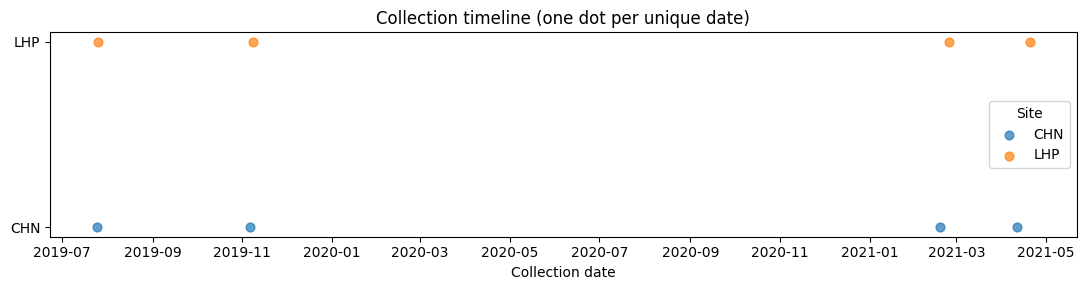

In [29]:
fig, ax = plt.subplots(figsize=(11, 3))

for label, df in [('CHN', chn), ('LHP', lhp)]:
    unique_dates = df['_date'].dropna().unique()
    ax.scatter(unique_dates, [label] * len(unique_dates),
               color=SITE_COLOURS[label], s=40, alpha=0.7, label=label)

ax.set_xlabel('Collection date')
ax.set_title('Collection timeline (one dot per unique date)')
ax.legend(title='Site')
plt.tight_layout()
plt.show()


In [30]:
# Oosorption rate per campaign (2019 vs 2021)
campaign_rows = []
for label, df in [('CHN', chn), ('LHP', lhp)]:
    for year, campaign in [(2019, '2019 (W/Sp)'), (2021, '2021 (Su/Au)')]:
        sub = df[df['_date'].dt.year == year]
        if len(sub) == 0:
            continue
        yes = sub['Oosorbtion'].eq('Yes').sum()
        campaign_rows.append({
            'Site': label, 'Campaign': campaign,
            'Total cuts': len(sub), 'Yes': yes,
            'Yes%': round(100 * yes / len(sub), 1),
        })
print(pd.DataFrame(campaign_rows).set_index(['Site', 'Campaign']).to_string())


                   Total cuts  Yes  Yes%
Site Campaign                           
CHN  2019 (W/Sp)         1015   78   7.7
     2021 (Su/Au)         942  126  13.4
LHP  2019 (W/Sp)          935   93   9.9
     2021 (Su/Au)        1200  198  16.5


**Confirmed:** Collection dates cluster into two campaigns (2019 and 2021) at both sites. Timeline and per-campaign oosorption rates shown above.

## 10 — Validation assertions

In [32]:
import os

checks = {
    'metadata/Liliguapi_oosorption.csv': 2135,
    'metadata/combined_oosorption.csv': len(chn) + len(lhp),
}
for rel_path, expected_rows in checks.items():
    df_check = pd.read_csv(BASE / rel_path, dtype=str)
    assert len(df_check) == expected_rows, (
        f'{rel_path}: expected {expected_rows} rows, got {len(df_check)}'
    )
    print(f'{rel_path}: {len(df_check)} rows')

assert 'Site' in pd.read_csv(BASE / 'metadata/combined_oosorption.csv').columns
print('combined_oosorption.csv has Site column')

# Summary files
for p in [
    'metadata/Liliguapi_oosorption_summary.md',
    'metadata/combined_oosorption.csv',
    'notebooks/metadata_analysis.ipynb',
]:
    assert (BASE / p).exists(), f'Missing: {p}'
    print(f'{p} exists')

print('\nAll validation assertions passed.')


metadata/Liliguapi_oosorption.csv: 2135 rows
metadata/combined_oosorption.csv: 4092 rows
combined_oosorption.csv has Site column
metadata/Liliguapi_oosorption_summary.md exists
metadata/combined_oosorption.csv exists
notebooks/metadata_analysis.ipynb exists

All validation assertions passed.
